# 1- Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from scipy.optimize import curve_fit

# 2- Import Dataset

In [2]:
full_test_60k_address = 'dynamic_analysis_L60kcP_siltech_A37kcP_custom_20260511_085338.csv'
full_test_60k_df = pd.read_csv(full_test_60k_address)

full_test_address = 'full_run_260428.csv'
full_test_df = pd.read_csv(full_test_address)

# 3- Define Functions

## 3-1 Plot Function

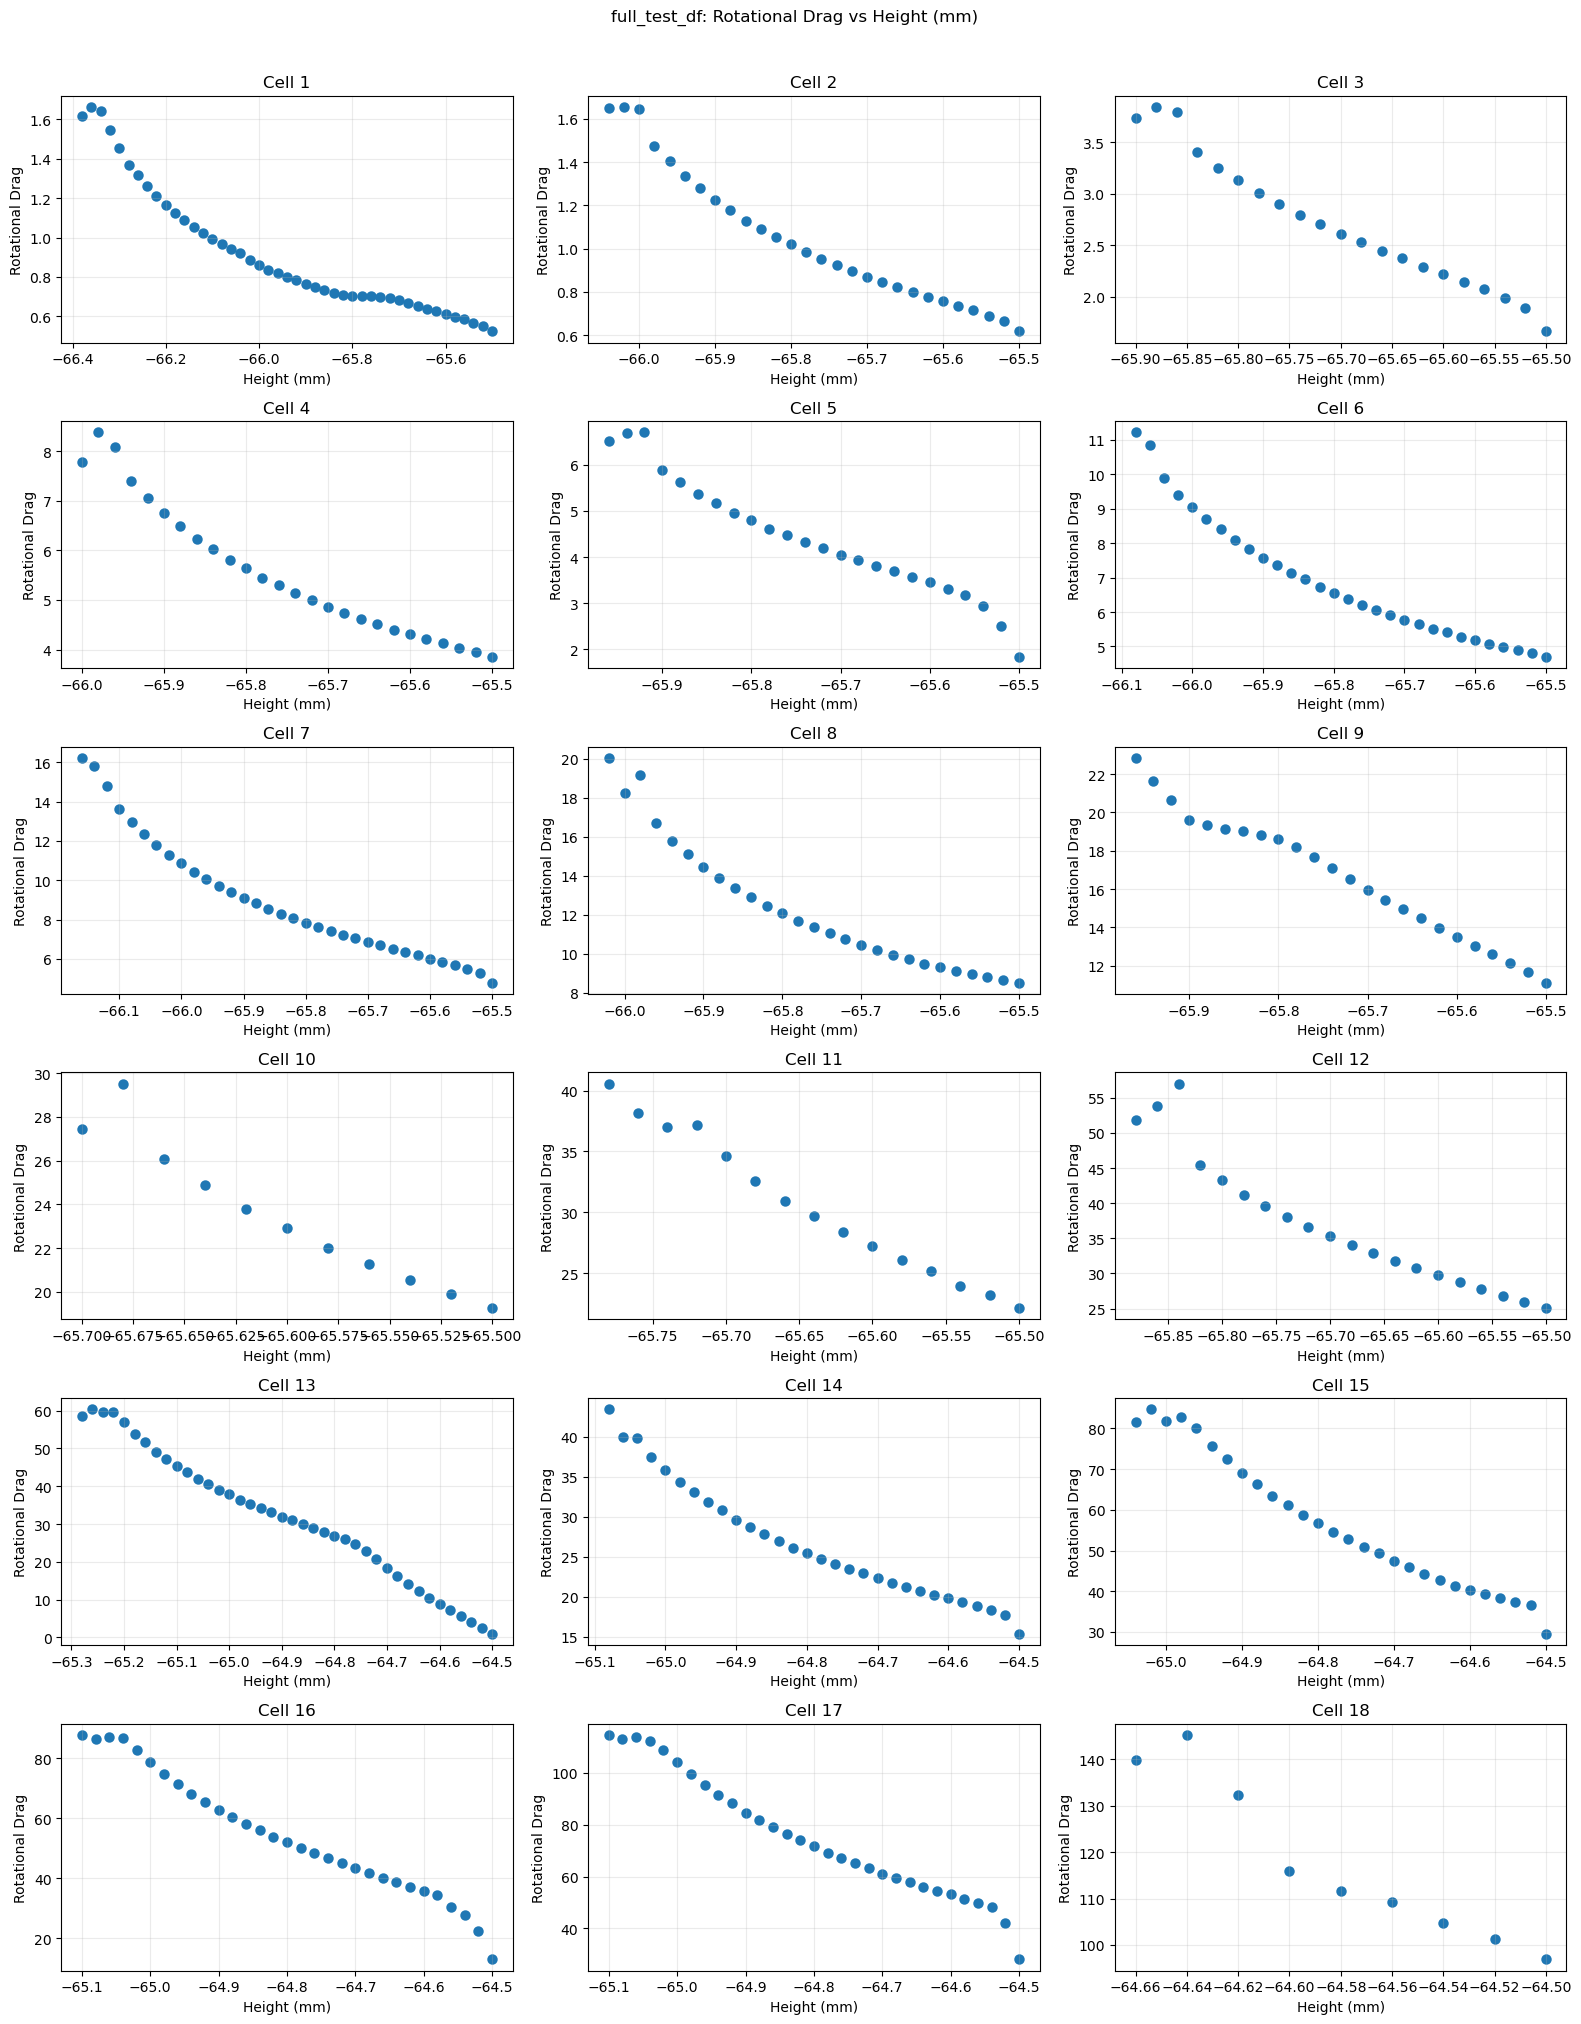

In [3]:
def plot_cells(df, name='dataset'):
    cc, xc, yc = 'cell', 'Z_Height_mm', 'Rotational_Drag'

    fig, axes = plt.subplots(6, 3, figsize=(16, 20))
    axes = axes.ravel()

    for i, ax in enumerate(axes, 1):
        g = df[df[cc].eq(i)]
        if g.empty: ax.axis('off'); continue
        ax.scatter(g[xc], g[yc], lw=1.5)
        ax.set_title(f'Cell {i}')
        ax.grid(alpha=.25)
        ax.set_xlabel('Height (mm)')
        ax.set_ylabel('Rotational Drag')
    fig.suptitle(f'{name}: Rotational Drag vs Height (mm)', y=1.01)

    plt.tight_layout()
    plt.show()

plot_cells(full_test_df, 'full_test_df')

## 3-2 X-axis Normalization

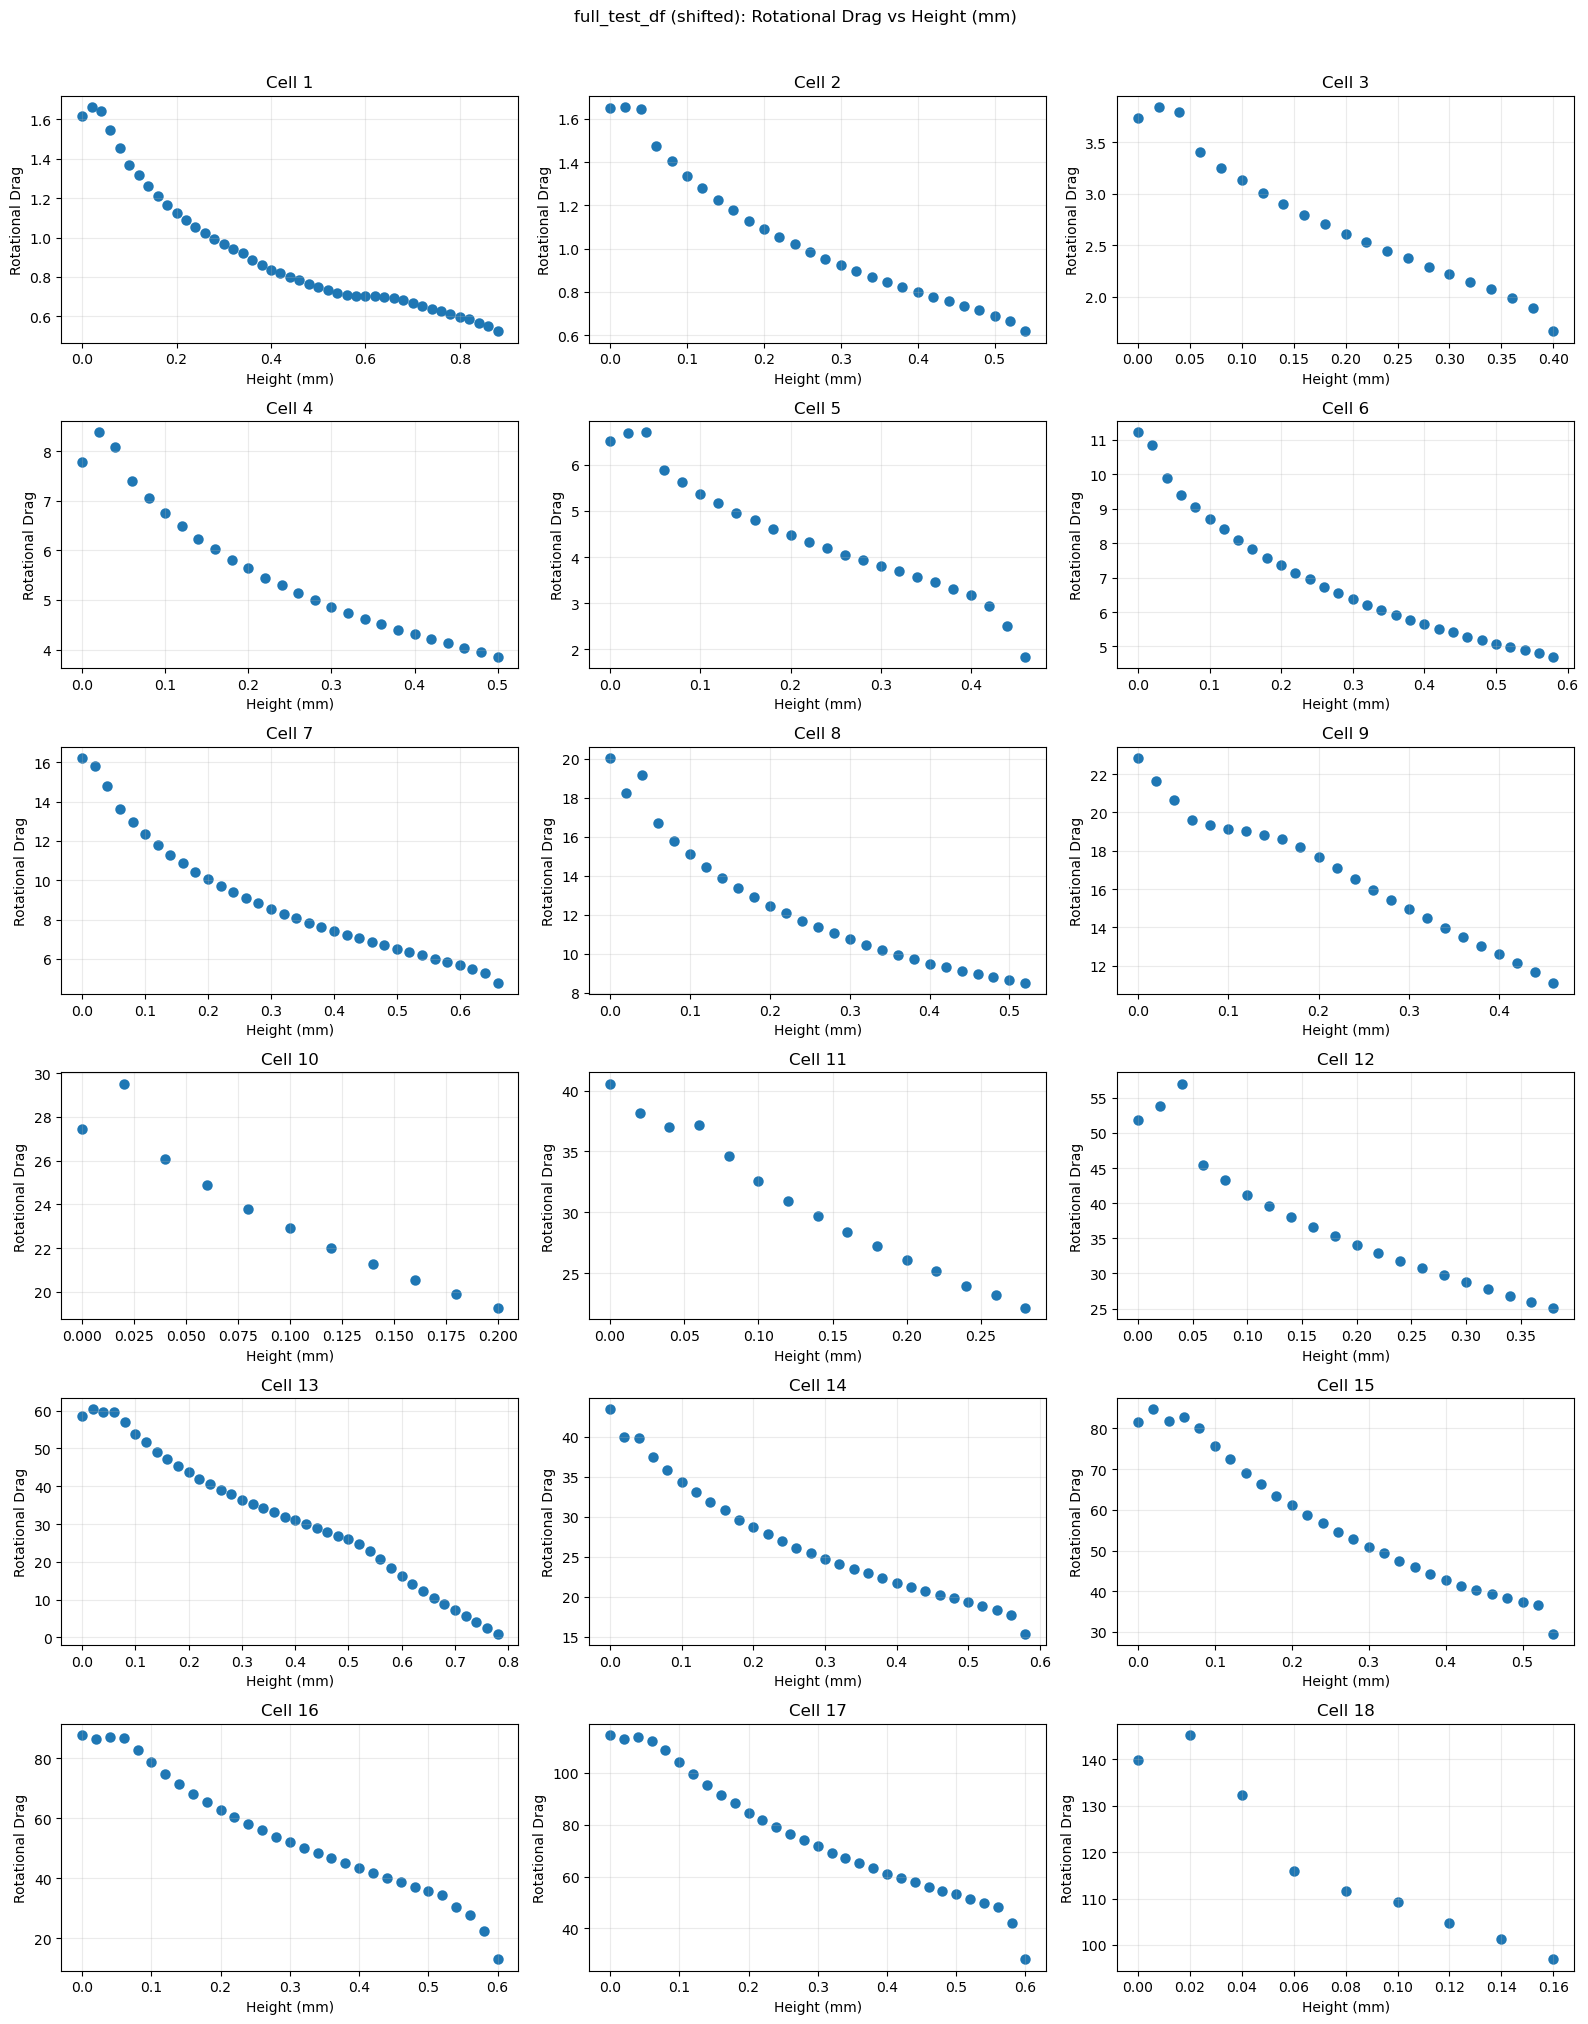

In [4]:
# Shift each cell curve so min Z_Height_mm becomes 0
full_test_df['Z_Height_mm'] = full_test_df.groupby('cell')['Z_Height_mm'].transform(lambda s: s - s.min())
plot_cells(full_test_df, 'full_test_df (shifted)')

## 3-3 Remove Before-Hit-Zone and After-Contact-Zone

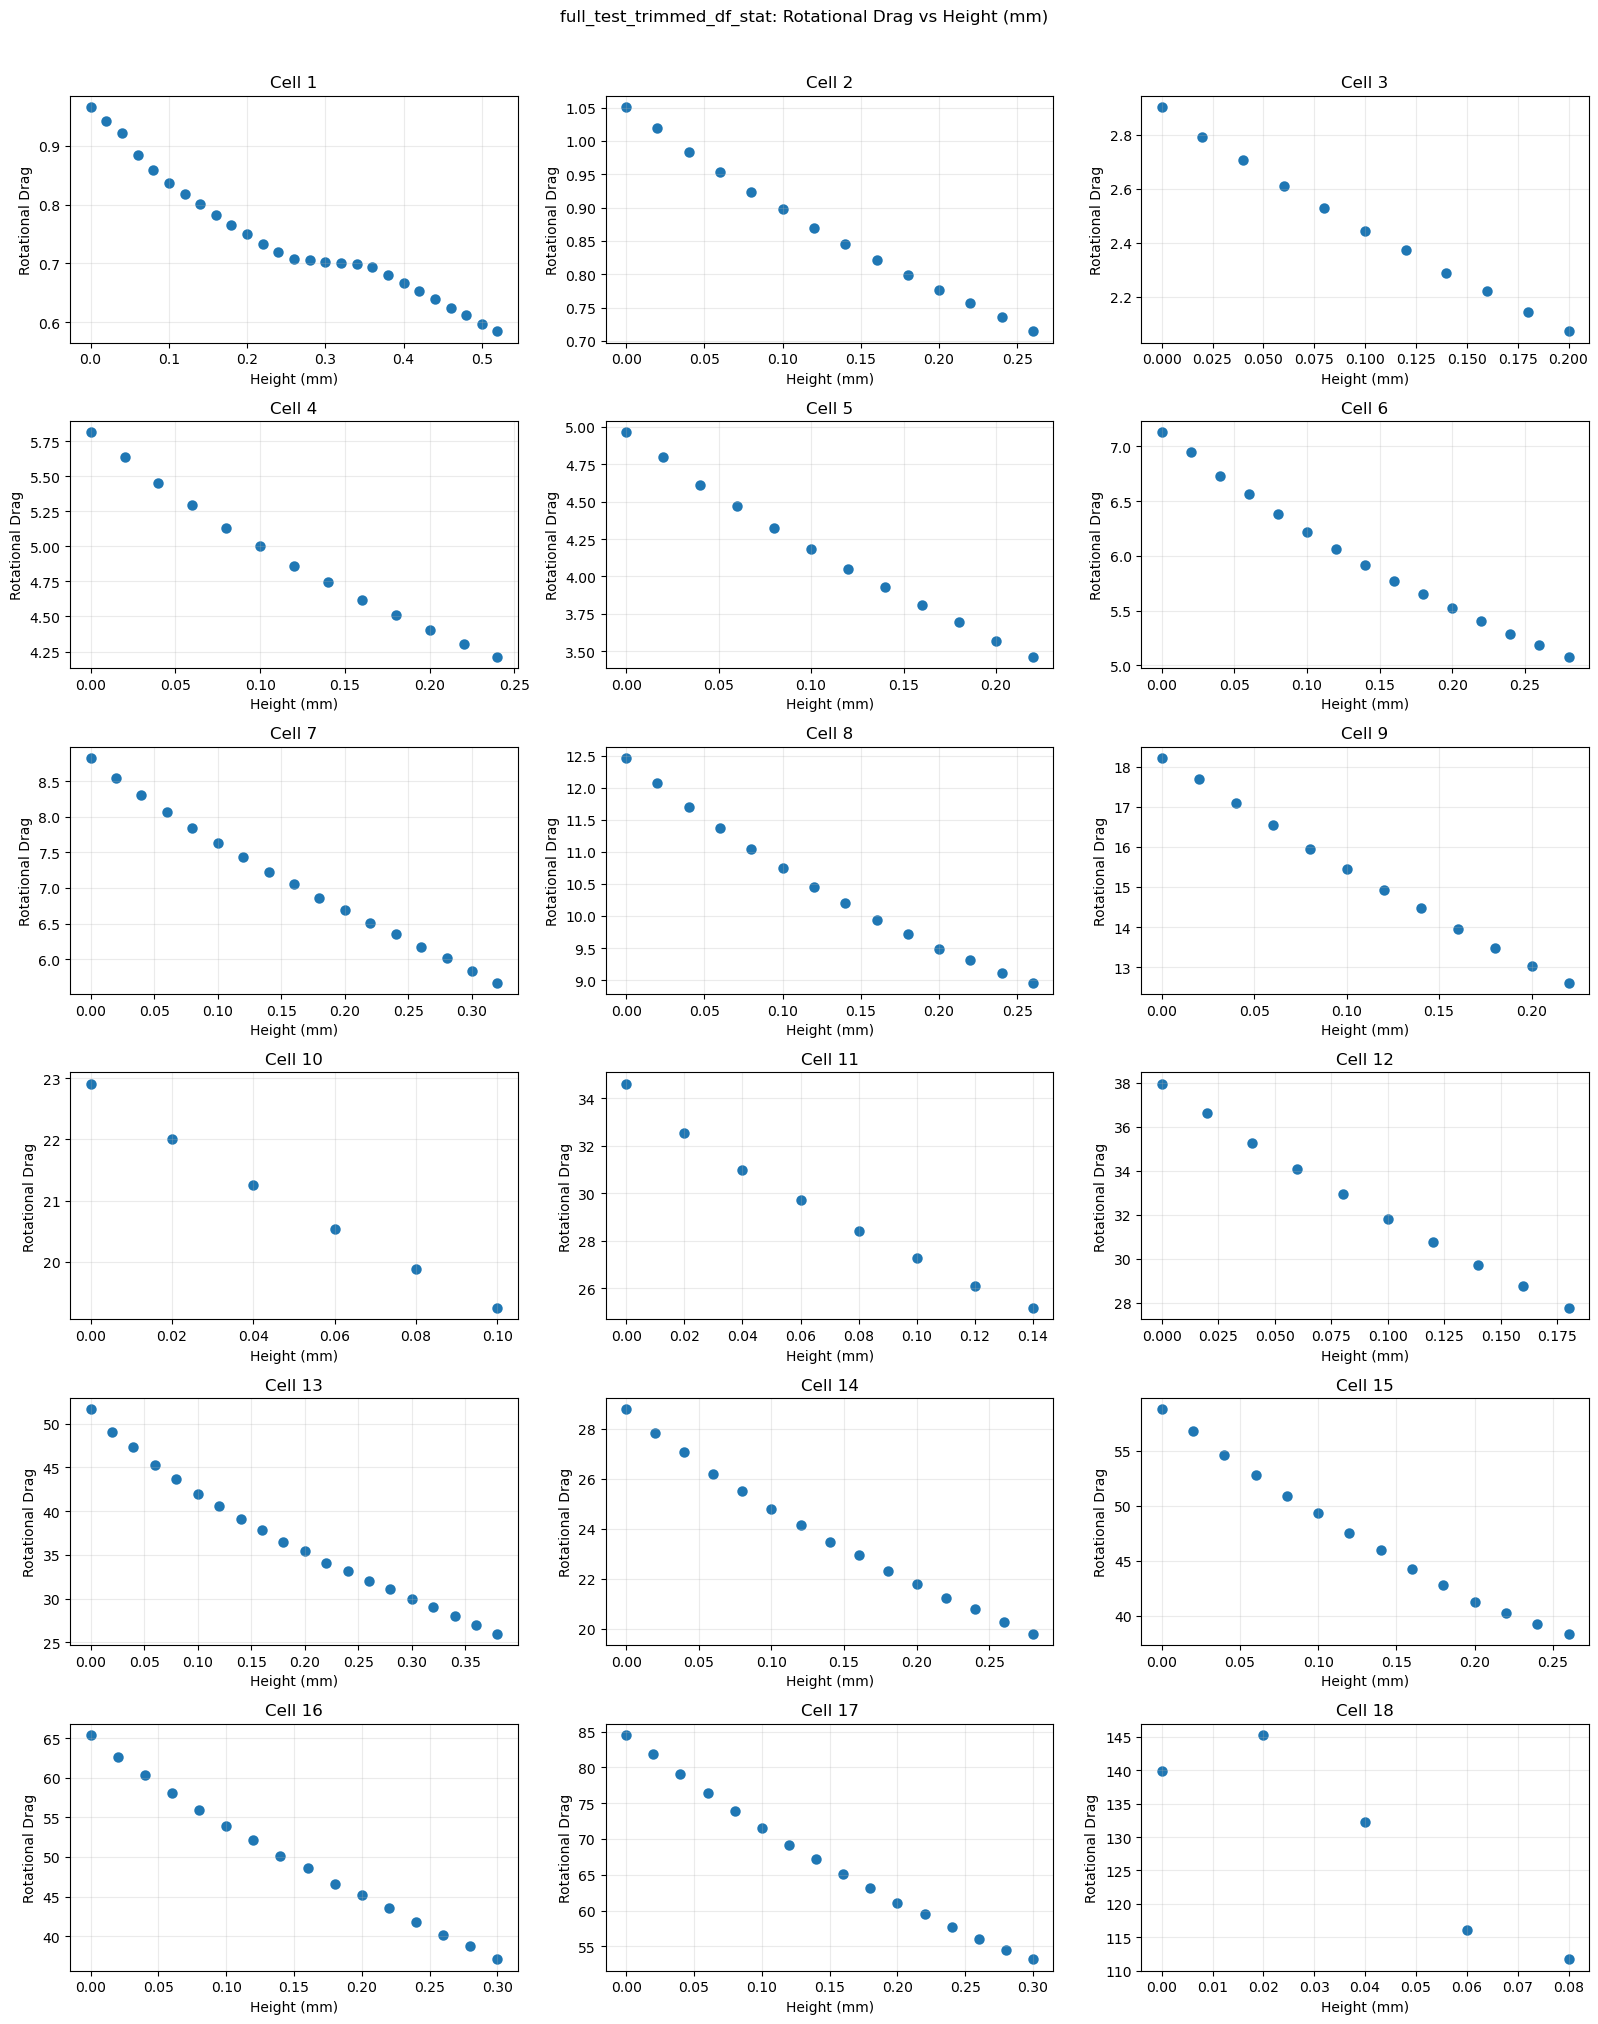

In [5]:
def trim_stat_middle(
    df,
    cell_col='cell',
    x_col='Z_Height_mm',
    y_col='Rotational_Drag',
    q=0.65,
    win=5,
    min_keep_frac=0.5,
    max_keep_frac=0.8,
):
    """General trim: keep the smoothest mostly decreasing middle segment; rebase x to start at 0."""
    out, rep, eps = [], [], 1e-9

    for cid, g in df.groupby(cell_col, sort=True):
        g = g.sort_values(x_col).reset_index(drop=True)
        x, y, n = g[x_col].to_numpy(float), g[y_col].to_numpy(float), len(g)

        if n < 6:
            sel = g.copy(); sel[x_col] -= sel[x_col].min()
            out.append(sel)
            rep.append({'cell': cid, 'start': 0, 'end': n - 1, 'kept': n, 'quality': np.nan})
            continue

        ys = pd.Series(y)
        y_sm = ys.rolling(win, center=True, min_periods=2).mean().bfill().ffill().to_numpy()
        sd = ys.rolling(win, center=True, min_periods=2).std().fillna(0).to_numpy()
        dy = np.gradient(y_sm, x)
        d2 = np.gradient(dy, x)

        cv = np.abs(sd / (np.abs(y_sm) + eps))
        d1_dev = np.abs(dy - np.nanmedian(dy))
        d2_abs = np.abs(d2)
        t_cv, t_d1, t_d2 = [np.nanquantile(v, q) for v in (cv, d1_dev, d2_abs)]
        neg = np.clip(-dy, 0, None)
        t_neg = max(np.nanquantile(neg, q), eps)

        raw = cv / (t_cv + eps) + d1_dev / (t_d1 + eps) + d2_abs / (t_d2 + eps) + 2.0 * np.clip(dy, 0, None) / t_neg - 0.8 * neg / t_neg

        min_k = max(5, int(np.ceil(min_keep_frac * n)))
        max_frac = 0.92 if n <= 14 else max_keep_frac
        max_k = min(n, max(min_k, int(np.floor(max_frac * n))))
        mid = 0.5 * (n - 1)

        best = (np.inf, 0, n)
        for L in range(min_k, max_k + 1):
            for i in range(0, n - L + 1):
                j = i + L
                dy_w = dy[i:j]
                pos_w = np.clip(dy_w, 0, None)
                neg_strength = float(np.nanmean(np.clip(-dy_w, 0, None)) / (t_neg + eps))
                score = float(np.nanmean(raw[i:j]))
                score += 1.8 * float(np.nanmean(pos_w / (t_neg + eps)))
                score += 0.9 * max(0.0, float(np.mean(dy_w > 0)) - 0.15)
                score += 0.35 * max(0.0, 0.55 - neg_strength)
                score += 0.10 * abs((i + j - 1) * 0.5 - mid) / max(n, 1)
                if score < best[0]:
                    best = (score, i, j)

        score, i, j = best
        sel = g.iloc[i:j].copy()
        sel[x_col] -= sel[x_col].min()

        out.append(sel)
        rep.append({'cell': cid, 'start': int(i), 'end': int(j - 1), 'kept': int(j - i), 'quality': float(score)})

    return pd.concat(out, ignore_index=True), pd.DataFrame(rep)

full_test_trimmed_df, full_test_trim_report = trim_stat_middle(full_test_df)
plot_cells(full_test_trimmed_df, 'full_test_trimmed_df_stat')

## 3-4 Fit 2nd-OrderPolynomial and Hyperbola

In [6]:
def fit_a_coefficients_by_cell(df, cell_col='cell', x_col='Z_Height_mm', y_col='Rotational_Drag'):
    def hyperbola(x, a, b):
        return a / (x - b)

    rows = []
    for cid, g in df.groupby(cell_col, sort=True):
        g = g.sort_values(x_col)
        x = g[x_col].to_numpy(float)
        y = g[y_col].to_numpy(float)

        poly_a = np.nan
        hyp_a = np.nan

        if len(g) >= 3:
            poly_a = float(np.polyfit(x, y, 2)[0])

        if len(g) >= 4 and np.ptp(x) > 0:
            # Initialize b away from x domain to avoid singularity during fitting.
            b0 = float(np.min(x) - 0.5 * max(np.ptp(x), 1e-6))
            a0 = float((y[0] - y[-1]) * max(np.ptp(x), 1e-6))
            lower_b = float(np.min(x) - 5.0 * max(np.ptp(x), 1e-6))
            upper_b = float(np.min(x) - 1e-6)

            try:
                p, _ = curve_fit(
                    hyperbola,
                    x,
                    y,
                    p0=[a0, b0],
                    bounds=([-np.inf, lower_b], [np.inf, upper_b]),
                    maxfev=20000,
                )
                hyp_a = float(p[0])
            except Exception:
                hyp_a = np.nan

        rows.append({'cell': int(cid), 'a_poly2': poly_a, 'a_hyperbola': hyp_a})

    return pd.DataFrame(rows).sort_values('cell').reset_index(drop=True)

cell_a_coefficients = fit_a_coefficients_by_cell(full_test_trimmed_df)
cell_a_coefficients

,cell,a_poly2,a_hyperbola
0,1,0.868767,0.828541
1,2,1.548535,0.588634
2,3,4.019021,1.488845
3,4,10.283467,3.645120
4,5,7.822022,2.567812
5,6,9.805869,4.908922
6,7,7.601738,5.307322
7,8,22.988616,8.104554
8,9,19.045834,9.209514
9,10,75.081295,11.488910


## 3-5 Visualize Fittings

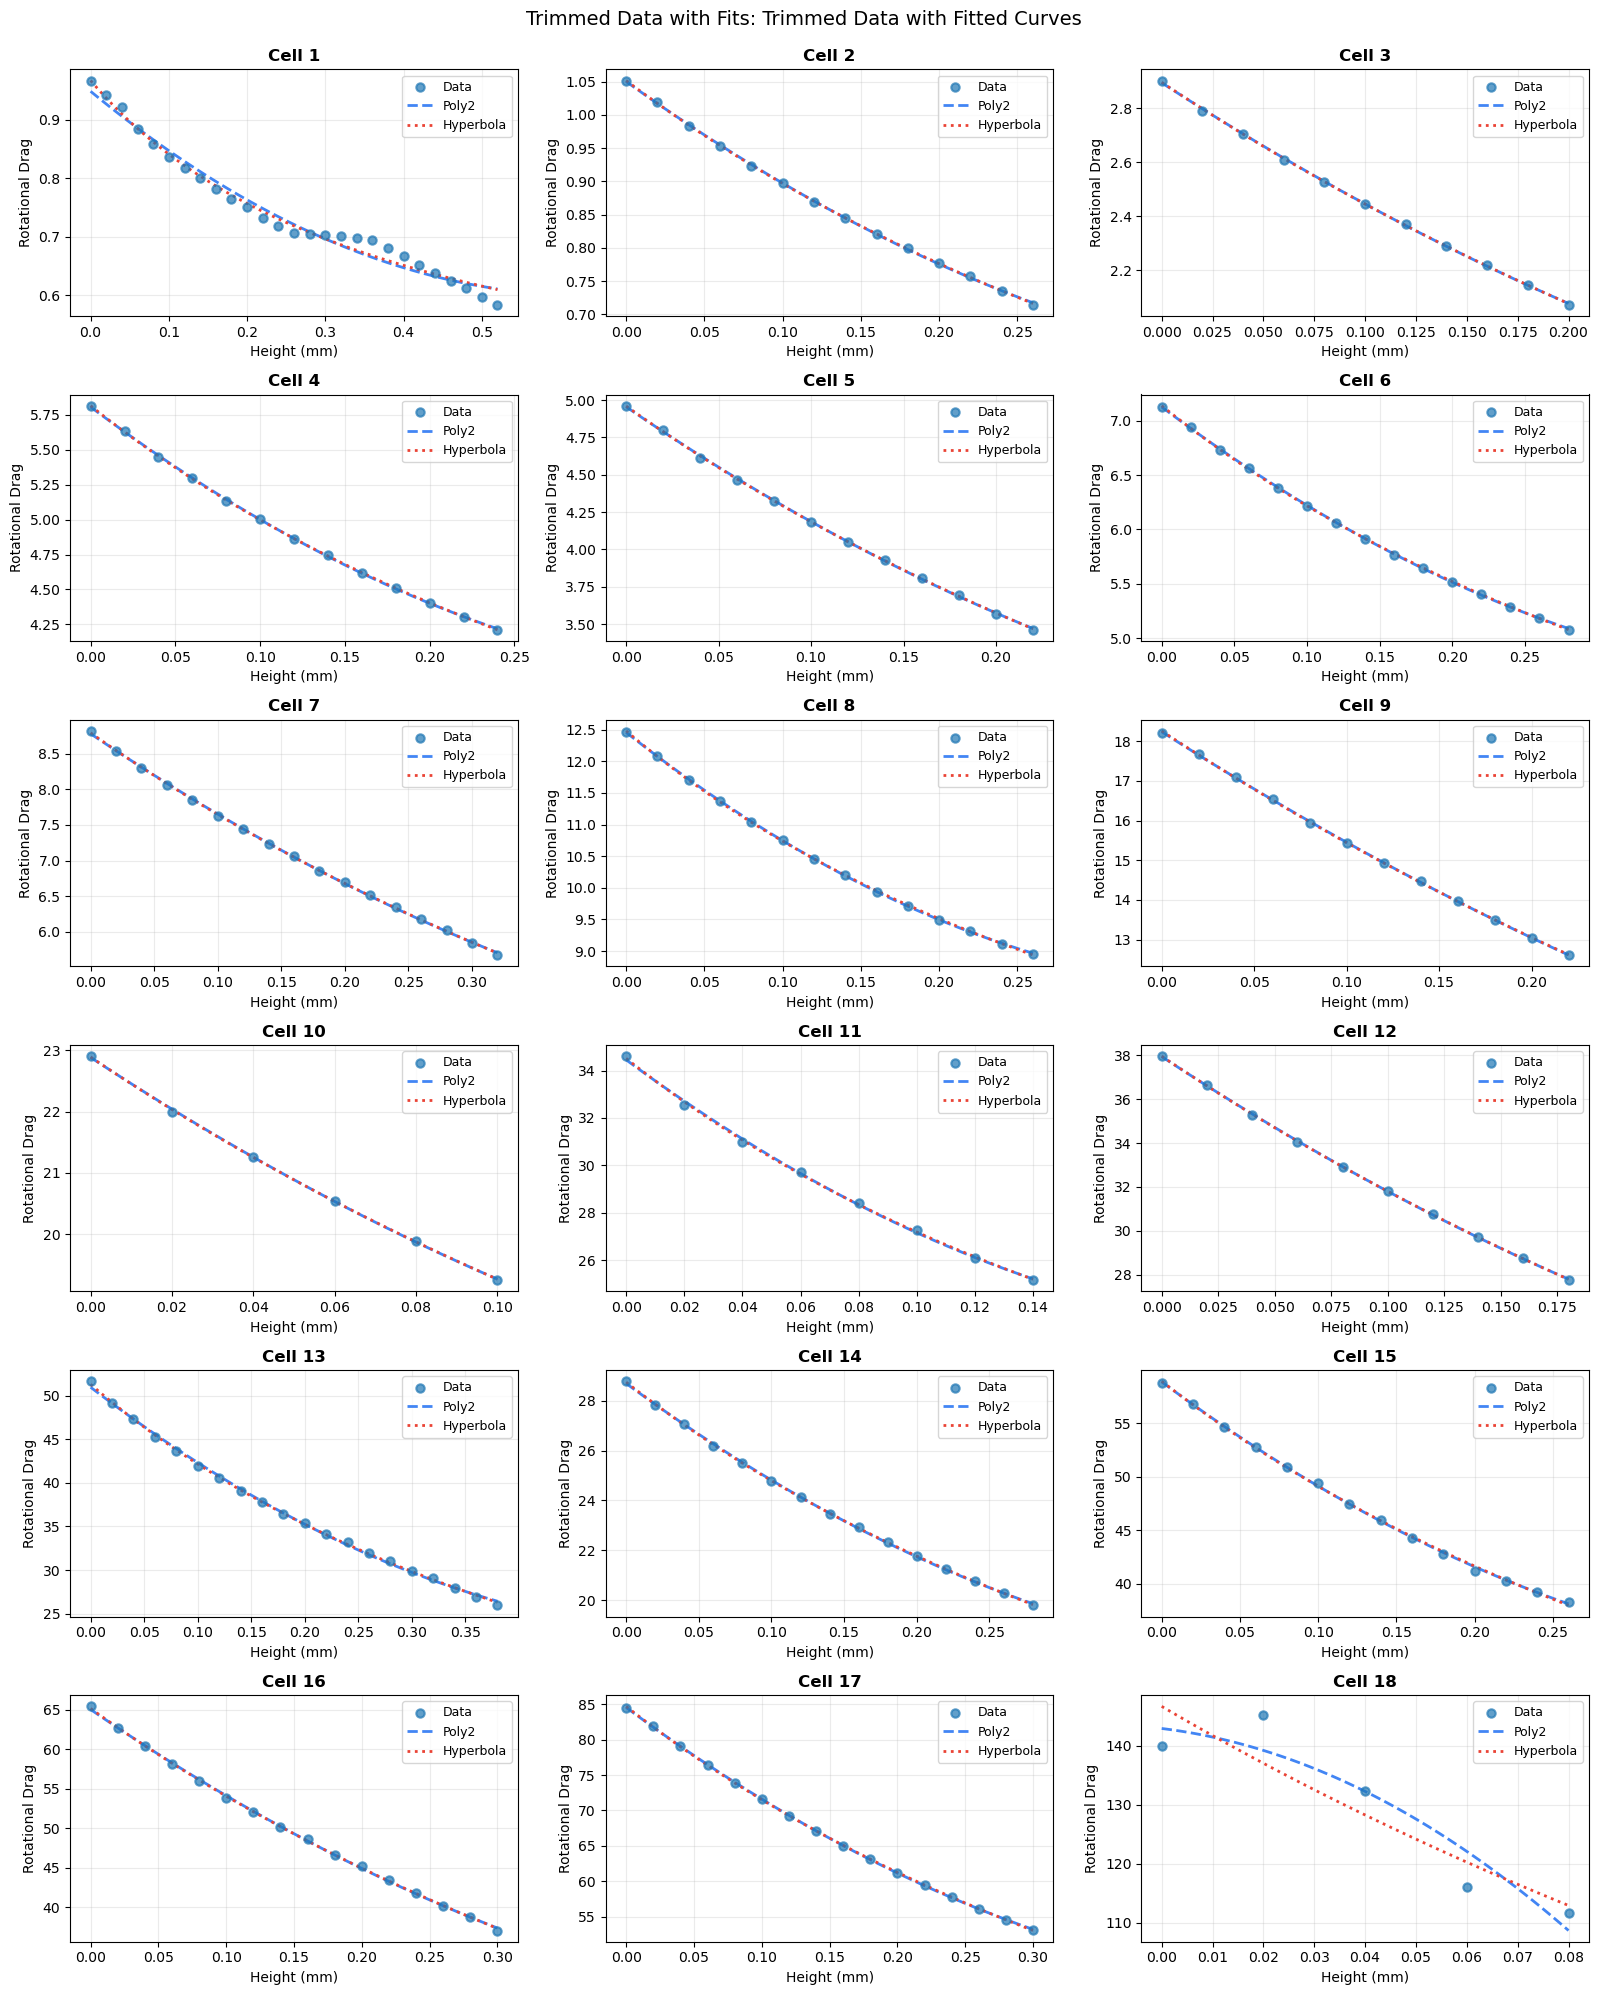

In [7]:
def plot_cells_with_fits(df, name='dataset'):
    """Plot trimmed data with polynomial and hyperbola fits overlaid."""
    from scipy.optimize import curve_fit
    
    cc, xc, yc = 'cell', 'Z_Height_mm', 'Rotational_Drag'
    def hyperbola(x, a, b, c):
        return a / (x - b) + c
    
    fig, axes = plt.subplots(6, 3, figsize=(16, 20))
    axes = axes.ravel()
    
    for i, ax in enumerate(axes, 1):
        g = df[df[cc].eq(i)].sort_values(xc)
        if g.empty:
            ax.axis('off')
            continue
        
        x = g[xc].to_numpy(float)
        y = g[yc].to_numpy(float)
        
        # Plot raw data
        ax.scatter(x, y, lw=1.5, alpha=0.7, label='Data', zorder=3)
        
        # Fit and plot polynomial
        if len(g) >= 3:
            p_poly = np.polyfit(x, y, 2)
            x_line = np.linspace(x.min(), x.max(), 100)
            y_poly = np.polyval(p_poly, x_line)
            ax.plot(x_line, y_poly, color='#4285F4', lw=2, linestyle='--', label='Poly2', zorder=2)
        
        # Fit and plot hyperbola
        if len(g) >= 4 and np.ptp(x) > 0:
            b0 = float(np.min(x) - 0.5 * max(np.ptp(x), 1e-6))
            a0 = float((y[0] - y[-1]) * max(np.ptp(x), 1e-6))
            c0 = float(np.nanmedian(y))
            lower_b = float(np.min(x) - 5.0 * max(np.ptp(x), 1e-6))
            upper_b = float(np.min(x) - 1e-6)
            try:
                p, _ = curve_fit(hyperbola, x, y, p0=[a0, b0, c0],
                                bounds=([-np.inf, lower_b, -np.inf], [np.inf, upper_b, np.inf]),
                                maxfev=20000)
                x_line = np.linspace(x.min(), x.max(), 100)
                y_hyp = hyperbola(x_line, *p)
                ax.plot(x_line, y_hyp, color='#EA4335', lw=2, linestyle=':', label='Hyperbola', zorder=2)
            except:
                pass
        
        ax.set_title(f'Cell {i}', fontsize=12, fontweight='bold')
        ax.grid(alpha=0.25)
        ax.set_xlabel('Height (mm)', fontsize=10)
        ax.set_ylabel('Rotational Drag', fontsize=10)
        ax.legend(fontsize=9, loc='best')
    
    fig.suptitle(f'{name}: Trimmed Data with Fitted Curves', y=0.995, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_cells_with_fits(full_test_trimmed_df, 'Trimmed Data with Fits')

## 3-6 Mapping Real Viscosity of Samples

In [8]:
real_viscosity_map = {
    1: 1000,
    2: 1154,
    3: 3347,
    4: 6611,
    5: 5865,
    6: 8930,
    7: 11860,
    8: 14590,
    9: 19000,
    10: 22730,
    11: 31870,
    12: 40850,
    13: 48520,
    14: 37020,
    15: 69080,
    16: 70730,
    17: 93270,
    18: 124800,
}

provider_map = {
    1: 'bluesil',
    2: 'siltech',
    3: 'sdl5',
    4: 'sdl5',
    5: 'bluesil',
    6: 'sdl5',
    7: 'siltech',
    8: 'sdl5',
    9: 'sdl5',
    10: 'sdl5',
    11: 'bluesil',
    12: 'sdl5',
    13: 'sdl5',
    14: 'siltech',
    15: 'bluesil',
    16: 'sdl5',
    17: 'sdl5',
    18: 'sigma',
}

cell_a_coefficients_enriched = cell_a_coefficients.copy()
cell_a_coefficients_enriched['real_viscosity'] = cell_a_coefficients_enriched['cell'].map(real_viscosity_map)
cell_a_coefficients_enriched['provider'] = cell_a_coefficients_enriched['cell'].map(provider_map)

cell_a_coefficients_enriched

,cell,a_poly2,a_hyperbola,real_viscosity,provider
0,1,0.868767,0.828541,1000,bluesil
1,2,1.548535,0.588634,1154,siltech
2,3,4.019021,1.488845,3347,sdl5
3,4,10.283467,3.645120,6611,sdl5
4,5,7.822022,2.567812,5865,bluesil
5,6,9.805869,4.908922,8930,sdl5
6,7,7.601738,5.307322,11860,siltech
7,8,22.988616,8.104554,14590,sdl5
8,9,19.045834,9.209514,19000,sdl5
9,10,75.081295,11.488910,22730,sdl5


# 4- Viscostiy Extrapolation

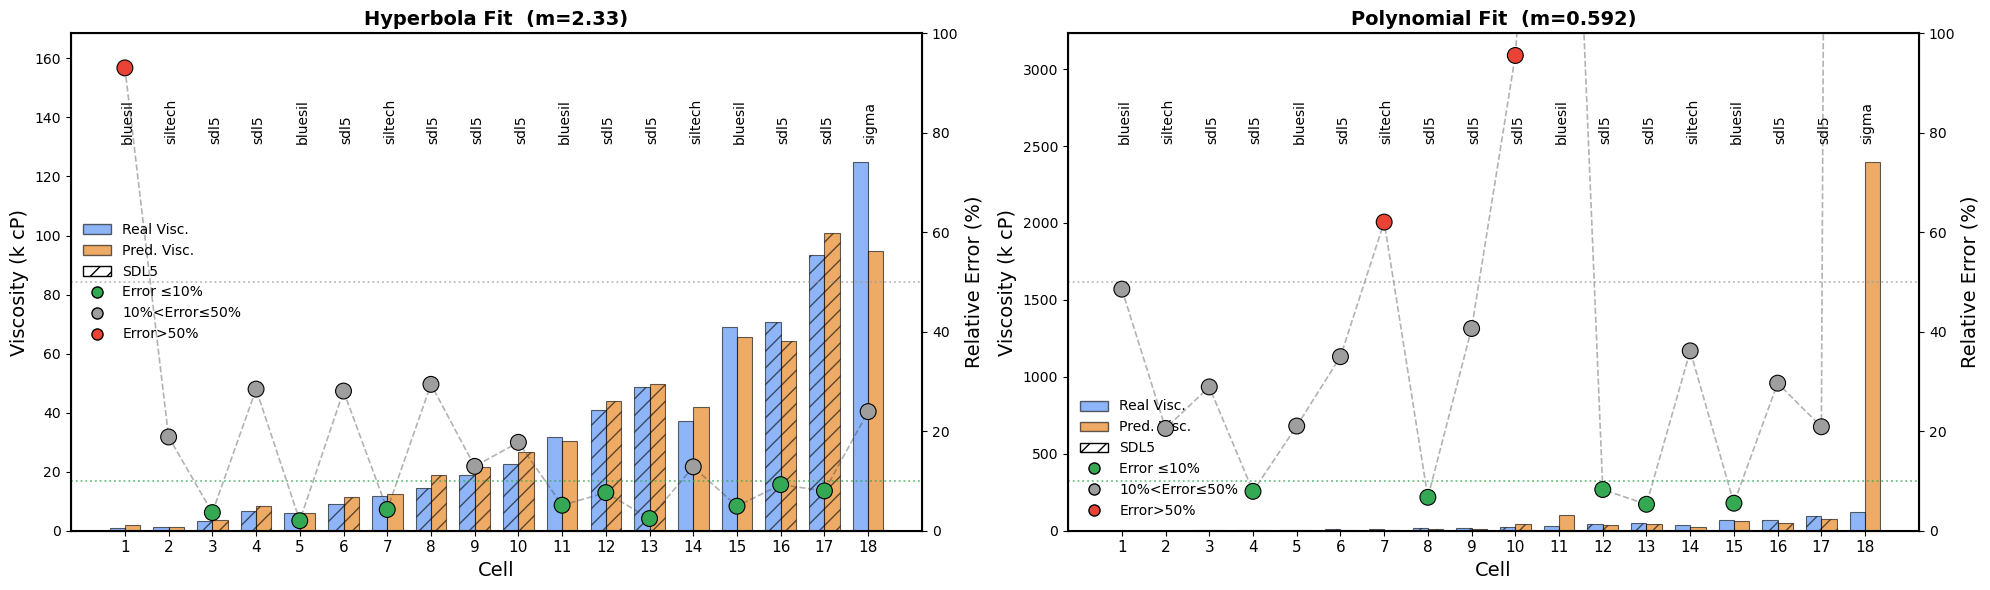

In [9]:
# Predict viscosity using hyperbola fit and visualize error
df_pred = cell_a_coefficients_enriched.dropna().copy()
m_hyp = 2.330  # Scaling factor to convert a_hyperbola to viscosity; determined empirically
m_pol2 = 0.592  # Scaling factor for polynomial fit

df_pred['predicted_visc_hyp'] = (m_hyp * df_pred['a_hyperbola']).abs() * 1000
df_pred['predicted_visc_pol'] = (m_pol2 * df_pred['a_poly2']).abs() * 1000

df_pred['rel_error_hyp'] = np.abs(df_pred['real_viscosity'] - df_pred['predicted_visc_hyp']) / df_pred['real_viscosity'] * 100
df_pred['rel_error_pol'] = np.abs(df_pred['real_viscosity'] - df_pred['predicted_visc_pol']) / df_pred['real_viscosity'] * 100

cells = df_pred['cell'].astype(int).values
real = df_pred['real_viscosity'].values / 1000
pred_hyp = df_pred['predicted_visc_hyp'].values / 1000
pred_pol = df_pred['predicted_visc_pol'].values / 1000
errs_hyp = df_pred['rel_error_hyp'].values
errs_pol = df_pred['rel_error_pol'].values
prov = df_pred['provider'].values

x = np.arange(len(cells))
bw = 0.35

fig, (ax_hyp, ax_pol) = plt.subplots(1, 2, figsize=(20, 6), sharey=False)

def draw_panel(ax, real, pred, errs, prov, cells, x, bw, title):
    for i in range(len(cells)):
        h = '//' if prov[i] == 'sdl5' else None
        ax.bar(x[i] - bw/2, real[i], bw, color='#4285F4', alpha=0.6, hatch=h, edgecolor='k', lw=0.8)
        ax.bar(x[i] + bw/2, pred[i], bw, color='#E37400', alpha=0.6, hatch=h, edgecolor='k', lw=0.8)

    y_max = max(real.max(), pred.max())
    for i, p in enumerate(prov):
        ax.text(x[i] + 0.06, y_max * 1.05, p, ha='center', va='bottom', fontsize=10, rotation=90)

    ax.set_ylabel('Viscosity (k cP)', fontsize=14)
    ax.set_xlabel('Cell', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(cells.astype(int), fontsize=11)
    ax.set_ylim(0, y_max * 1.35)
    ax.grid(False)
    ax.set_title(title, fontsize=14, fontweight='bold')

    ax2 = ax.twinx()
    colors = ['#34A853' if e <= 10 else '#9E9E9E' if e <= 50 else '#EA4335' for e in errs]
    ax2.scatter(x, errs, color=colors, s=130, zorder=5, edgecolor='k', lw=0.8)
    ax2.plot(x, errs, color='#3C4043', lw=1.2, linestyle='--', alpha=0.4)
    ax2.set_ylabel('Relative Error (%)', fontsize=14)
    ax2.axhline(10, color='#34A853', linestyle=':', lw=1.3, alpha=0.7)
    ax2.axhline(50, color='#9E9E9E', linestyle=':', lw=1.3, alpha=0.7)
    ax2.set_ylim(0, 100)

    leg = [
        Patch(facecolor='#4285F4', alpha=0.6, edgecolor='k', label='Real Visc.'),
        Patch(facecolor='#E37400', alpha=0.6, edgecolor='k', label='Pred. Visc.'),
        Patch(facecolor='white', hatch='//', edgecolor='k', label='SDL5'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#34A853', markeredgecolor='k', markersize=8, label='Error ≤10%'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#9E9E9E', markeredgecolor='k', markersize=8, label='10%<Error≤50%'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#EA4335', markeredgecolor='k', markersize=8, label='Error>50%'),
    ]
    ax.legend(handles=leg, fontsize=10, frameon=False)

    for sp in ax.spines.values():
        sp.set_linewidth(1.5)

draw_panel(ax_hyp, real, pred_hyp, errs_hyp, prov, cells, x, bw, f'Hyperbola Fit  (m={m_hyp})')
draw_panel(ax_pol, real, pred_pol, errs_pol, prov, cells, x, bw, f'Polynomial Fit  (m={m_pol2})')

plt.tight_layout()
plt.show()


# Supplementary: Correlation of Viscosity with Hyperbola-Factor and Polynomial-Factor

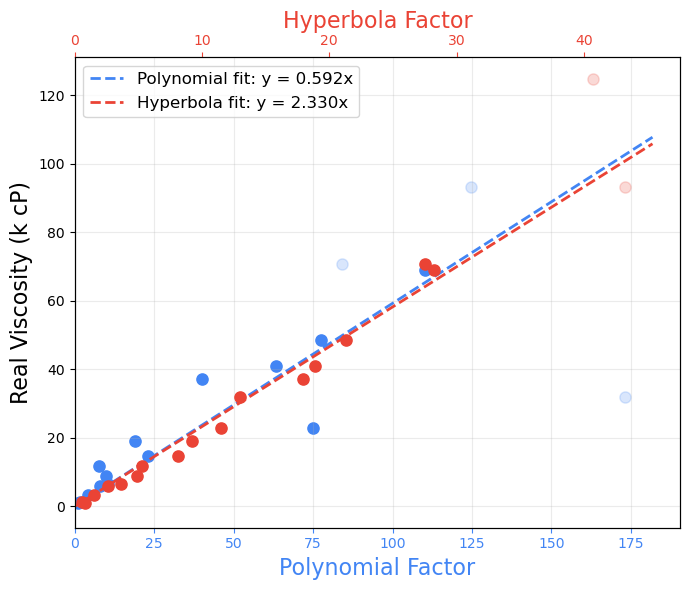

In [10]:
# Dual-x scatter with 1-std outlier filtering, then origin-constrained fits
df_plot = cell_a_coefficients_enriched.dropna(subset=['real_viscosity', 'a_poly2', 'a_hyperbola']).copy()
df_plot['real_viscosity_kcp'] = df_plot['real_viscosity'] / 1000.0

fig, ax_bottom = plt.subplots(figsize=(7, 6))
ax_top = ax_bottom.twiny()

google_blue = '#4285F4'
google_red = '#EA4335'

x_poly = df_plot['a_poly2'].to_numpy(float)
x_hyp = df_plot['a_hyperbola'].to_numpy(float)
y_kcp = df_plot['real_viscosity_kcp'].to_numpy(float)

# Keep positive factors to match displayed x-domains.
mask_poly = x_poly > 0
mask_hyp = x_hyp > 0

xp, yp = x_poly[mask_poly], y_kcp[mask_poly]
xh, yh = x_hyp[mask_hyp], y_kcp[mask_hyp]

# Initial origin-constrained fits.
m_poly_0 = float(np.sum(xp * yp) / np.sum(xp ** 2))
m_hyp_0 = float(np.sum(xh * yh) / np.sum(xh ** 2))

# Outlier detection: residual farther than 1 std from expectation.
res_poly = yp - m_poly_0 * xp
res_hyp = yh - m_hyp_0 * xh
thr_poly = np.std(res_poly)
thr_hyp = np.std(res_hyp)
in_poly = np.abs(res_poly) <= thr_poly
in_hyp = np.abs(res_hyp) <= thr_hyp

# Refit with inliers only (still through origin).
m_poly = float(np.sum(xp[in_poly] * yp[in_poly]) / np.sum(xp[in_poly] ** 2))
m_hyp = float(np.sum(xh[in_hyp] * yh[in_hyp]) / np.sum(xh[in_hyp] ** 2))

# Plot inliers as solid and outliers as transparent.
alpha_in = 1.0
alpha_out = 0.2

ax_bottom.scatter(xp[in_poly], yp[in_poly], color=google_blue, s=65, alpha=alpha_in)
ax_bottom.scatter(xp[~in_poly], yp[~in_poly], color=google_blue, s=65, alpha=alpha_out)

ax_top.scatter(xh[in_hyp], yh[in_hyp], color=google_red, s=65, alpha=alpha_in)
ax_top.scatter(xh[~in_hyp], yh[~in_hyp], color=google_red, s=65, alpha=alpha_out)

x_poly_line = np.linspace(0, xp.max() * 1.05, 200)
x_hyp_line = np.linspace(0, xh.max() * 1.05, 200)

l1, = ax_bottom.plot(
    x_poly_line,
    m_poly * x_poly_line,
    color=google_blue,
    lw=2,
    linestyle='--',
    label=f'Polynomial fit: y = {m_poly:.3f}x'
)
l2, = ax_top.plot(
    x_hyp_line,
    m_hyp * x_hyp_line,
    color=google_red,
    lw=2,
    linestyle='--',
    label=f'Hyperbola fit: y = {m_hyp:.3f}x'
)

ax_bottom.set_xlabel('Polynomial Factor', fontsize=16, color=google_blue)
ax_top.set_xlabel('Hyperbola Factor', fontsize=16, color=google_red)
ax_bottom.set_ylabel('Real Viscosity (k cP)', fontsize=16)

ax_bottom.tick_params(axis='x', colors=google_blue)
ax_top.tick_params(axis='x', colors=google_red)
ax_bottom.grid(alpha=0.25)
ax_bottom.set_xlim(left=0, right=xp.max() * 1.1)
ax_top.set_xlim(left=0, right=xh.max() * 1.1)

ax_bottom.legend(handles=[l1, l2], loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

# 5- Helper Pipeline Example (Reusable)

This section uses a helper module to run the full workflow on any CSV with the same schema:
1. load dataset
2. normalize x-axis per cell
3. trim before-hit and after-contact zones
4. fit Polynomial(2nd) and Hyperbola
5. map real viscosity (entered by user)
6. extrapolate viscosity for unknown cells
7. plot selected raw segments + fits
8. plot prediction accuracy for both methods

In [ ]:
from pathlib import Path
import sys

import pandas as pd

# Ensure helper module is importable when notebook working directory changes.
candidate_dirs = [
    Path.cwd(),
    Path.cwd() / 'results' / 'Auto-runs',
    Path.cwd().parent,
]
helper_dir = next((d for d in candidate_dirs if (d / 'viscosity_pipeline_helper.py').exists()), None)
if helper_dir is None:
    raise FileNotFoundError('Could not locate viscosity_pipeline_helper.py')
if str(helper_dir) not in sys.path:
    sys.path.insert(0, str(helper_dir))

from viscosity_pipeline_helper import run_viscosity_pipeline

# ---- USER INPUT: known real viscosities in cP (calibration cells) ----
real_viscosity_map = {
    1: 1000,
    2: 1154,
    3: 3347,
    4: 6611,
    5: 5865,
    6: 8930,
    7: 11860,
    8: 14590,
    9: 19000,
    10: 22730,
    11: 31870,
    12: 40850,
    13: 48520,
}

# Example dataset. Replace with any real rotational-drag CSV with the same columns.
csv_path = 'full_run_260428.csv'

pipeline_out = run_viscosity_pipeline(
    csv_path=csv_path,
    real_viscosity_map=real_viscosity_map,
    visualize=True,
)

# Table with fitted factors and predicted viscosities (for both known and unknown cells).
pred_cols = [
    'cell',
    'a_poly2',
    'a_hyperbola',
    'real_viscosity',
    'predicted_visc_pol',
    'predicted_visc_hyp',
    'rel_error_pol',
    'rel_error_hyp',
    'is_calibration',
]

display(
    pipeline_out['predictions'][pred_cols]
    .sort_values('cell')
    .reset_index(drop=True)
)

print('Learned scaling factors:', pipeline_out['scales'])
print('Tip: remove some cells from real_viscosity_map to test extrapolation on unknown samples.')